# Modelado

### Librerias 

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum
from pyspark.sql import types as T
from pyspark.sql import functions as F
from sklearn.model_selection import train_test_split


## **Iniciamos la Sesión Spark**

In [2]:
sparks = (SparkSession.builder
         .appName("Pyspark session")
         .getOrCreate())

Creamos una sesión de spark para trabajar con los dataframes y utilizar todas las funciones de Pyspark

## **Lectura de Datos**

In [3]:
df = sparks.read.csv("accepted_2007_to_2018Q4.csv", header=True, inferSchema=True)


Cargamos los datos como un dataframe de Spark

## **Creacion Variable `default`**

In [4]:
df = df.filter((col("loan_status") == "Fully Paid") | 
               (col("loan_status") == "Charged Off"))

Filtramos los valores de **Fully Paid** y **Charged Off** de la variable `loan_status`

In [5]:
df = df.withColumn(
    "default",
    when(col("loan_status") == "Charged Off", 1).otherwise(0)
)

Definimos los valores **Charged off = 1** y **Fully Paid = 0** para la variable nueva `default` 

## **Limpieza de Nombres y Eliminacion de Variables**

In [6]:
traductor = {
    "id": "id",
    "member_id": "id_miembro",
    "loan_amnt": "monto_prestamo",
    "funded_amnt": "monto_aprobado",
    "funded_amnt_inv": "monto_inversionistas",
    "term": "plazo",
    "int_rate": "tasa_interes",
    "installment": "cuota_mensual",
    "grade": "calificacion",
    "sub_grade": "sub_calificacion",
    "emp_title": "titulo_empleo",
    "emp_length": "antiguedad_empleo",
    "home_ownership": "tenencia_vivienda",
    "annual_inc": "ingreso_anual",
    "verification_status": "estado_verificacion",
    "issue_d": "fecha_emision",
    "loan_status": "estado_prestamo",
    "pymnt_plan": "plan_pago",
    "url": "url",
    "desc": "descripcion",
    "purpose": "proposito",
    "title": "titulo_prestamo",
    "zip_code": "codigo_postal",
    "addr_state": "estado_residencia",
    "dti": "ratio_deuda_ingreso",
    "delinq_2yrs": "morosidad_2_anios",
    "earliest_cr_line": "primer_linea_credito",
    "inq_last_6mths": "consultas_ultimos6m",
    "mths_since_last_delinq": "meses_ultimo_incumplimiento",
    "mths_since_last_record": "meses_ultimo_registro",
    "open_acc": "cuentas_abiertas",
    "pub_rec": "registros_publicos",
    "revol_bal": "saldo_revolvente",
    "revol_util": "utilizacion_revolvente",
    "total_acc": "total_cuentas",
    "initial_list_status": "estado_inicial_lista",
    "out_prncp": "capital_pendiente",
    "out_prncp_inv": "capital_pendiente_inversionistas",
    "total_pymnt": "pago_total",
    "total_pymnt_inv": "pago_total_inversionistas",
    "total_rec_prncp": "capital_pagado",
    "total_rec_int": "intereses_pagados",
    "total_rec_late_fee": "mora_pagada",
    "recoveries": "recuperaciones",
    "collection_recovery_fee": "gastos_recuperacion",
    "last_pymnt_d": "fecha_ultimo_pago",
    "last_pymnt_amnt": "monto_ultimo_pago",
    "next_pymnt_d": "fecha_proximo_pago",
    "last_credit_pull_d": "fecha_ultima_consulta_credito",
    "collections_12_mths_ex_med": "cobranzas_12m_excl_med",
    "mths_since_last_major_derog": "meses_ultimo_informe_negativo",
    "policy_code": "codigo_politica",
    "application_type": "tipo_aplicacion",
    "annual_inc_joint": "ingreso_anual_conjunto",
    "dti_joint": "ratio_deuda_ingreso_conjunto",
    "verification_status_joint": "estado_verificacion_conjunto",
    "acc_now_delinq": "cuentas_en_morosidad",
    "tot_coll_amt": "monto_total_cobranzas",
    "tot_cur_bal": "saldo_total_actual",
    "open_acc_6m": "cuentas_abiertas_6m",
    "open_il_6m": "cuentas_instalacion_6m",
    "open_il_12m": "cuentas_instalacion_12m",
    "open_il_24m": "cuentas_instalacion_24m",
    "mths_since_rcnt_il": "meses_ultima_cuenta_instalacion",
    "total_bal_il": "saldo_total_instalacion",
    "il_util": "utilizacion_instalacion",
    "open_rv_12m": "cuentas_revolving_12m",
    "open_rv_24m": "cuentas_revolving_24m",
    "max_bal_bc": "saldo_max_tarjeta",
    "all_util": "utilizacion_total",
    "total_rev_hi_lim": "limite_total_revolving",
    "inq_fi": "consultas_financieras",
    "total_cu_tl": "total_lineas_credito",
    "inq_last_12m": "consultas_12m",
    "acc_open_past_24mths": "cuentas_abiertas_24m",
    "avg_cur_bal": "saldo_promedio_actual",
    "bc_open_to_buy": "credito_disponible_bc",
    "bc_util": "utilizacion_tarjetas_bc",
    "chargeoff_within_12_mths": "castigos_12m",
    "delinq_amnt": "monto_morosidad",
    "mo_sin_old_il_acct": "meses_cuenta_instalacion_mas_antigua",
    "mo_sin_old_rev_tl_op": "meses_cuenta_revolving_mas_antigua",
    "mo_sin_rcnt_rev_tl_op": "meses_ultima_cuenta_revolving",
    "mo_sin_rcnt_tl": "meses_ultima_linea_credito",
    "mort_acc": "cuentas_hipotecarias",
    "mths_since_recent_bc": "meses_ultima_tarjeta_bc",
    "mths_since_recent_bc_dlq": "meses_mora_tarjeta_bc",
    "mths_since_recent_inq": "meses_ultima_consulta",
    "mths_since_recent_revol_delinq": "meses_mora_revolving",
    "num_accts_ever_120_pd": "cuentas_mas_120_dias",
    "num_actv_bc_tl": "cuentas_bc_activas",
    "num_actv_rev_tl": "cuentas_revolving_activas",
    "num_bc_sats": "cuentas_bc_satisfechas",
    "num_bc_tl": "cuentas_bc_totales",
    "num_il_tl": "cuentas_instalacion_totales",
    "num_op_rev_tl": "cuentas_revolving_abiertas",
    "num_rev_accts": "cuentas_revolving",
    "num_rev_tl_bal_gt_0": "cuentas_revolving_saldo_gt_0",
    "num_sats": "cuentas_satisfechas",
    "num_tl_120dpd_2m": "cuentas_120_dias_2m",
    "num_tl_30dpd": "cuentas_30_dias",
    "num_tl_90g_dpd_24m": "cuentas_90_dias_24m",
    "num_tl_op_past_12m": "cuentas_abiertas_12m",
    "pct_tl_nvr_dlq": "pct_lineas_nunca_mora",
    "percent_bc_gt_75": "pct_bc_utilizacion_gt_75",
    "pub_rec_bankruptcies": "bancarrotas_publicas",
    "tax_liens": "gravamenes_impuestos",
    "tot_hi_cred_lim": "limite_total_credito_alto",
    "total_bal_ex_mort": "saldo_total_ex_mortgage",
    "total_bc_limit": "limite_total_bc",
    "total_il_high_credit_limit": "limite_total_instalacion_alto",
    "revol_bal_joint": "saldo_revolving_conjunto",
    "sec_app_fico_range_low": "fico_bajo_codeudor",
    "sec_app_fico_range_high": "fico_alto_codeudor",
    "sec_app_earliest_cr_line": "primer_credito_codeudor",
    "sec_app_inq_last_6mths": "consultas_6m_codeudor",
    "sec_app_mort_acc": "cuentas_hipoteca_codeudor",
    "sec_app_open_acc": "cuentas_abiertas_codeudor",
    "sec_app_revol_util": "utilizacion_revolving_codeudor",
    "sec_app_open_il_6m": "instalacion_6m_codeudor",
    "sec_app_num_rev_accts": "num_revolving_codeudor",
    "sec_app_chargeoff_within_12_mths": "castigos_12m_codeudor",
    "sec_app_collections_12_mths_ex_med": "cobranzas_12m_excl_med_codeudor",
    "sec_app_mths_since_last_major_derog": "meses_incumplimiento_codeudor",
    "hardship_flag": "bandera_dificultad",
    "hardship_type": "tipo_dificultad",
    "hardship_reason": "razon_dificultad",
    "hardship_status": "estado_dificultad",
    "deferral_term": "plazo_prorroga",
    "hardship_amount": "monto_dificultad",
    "hardship_start_date": "fecha_inicio_dificultad",
    "hardship_end_date": "fecha_fin_dificultad",
    "payment_plan_start_date": "fecha_inicio_plan_pago",
    "hardship_length": "duracion_dificultad",
    "hardship_dpd": "dias_mora_dificultad",
    "hardship_loan_status": "estado_prestamo_dificultad",
    "orig_projected_additional_accrued_interest": "interes_proyectado_adicional",
    "hardship_payoff_balance_amount": "monto_saldo_pago_dificultad",
    "hardship_last_payment_amount": "monto_ultimo_pago_dificultad",
    "disbursement_method": "metodo_desembolso",
    "debt_settlement_flag": "bandera_acuerdo_deuda",
    "debt_settlement_flag_date": "fecha_bandera_acuerdo_deuda",
    "settlement_status": "estado_acuerdo",
    "settlement_date": "fecha_acuerdo",
    "settlement_amount": "monto_acuerdo",
    "settlement_percentage": "porcentaje_acuerdo",
    "settlement_term": "plazo_acuerdo",
    "default": "incumplimiento"
}
for col_old, col_new in traductor.items():
    if col_old in df.columns:
        df = df.withColumnRenamed(col_old, col_new)

Hacemos el cambio de las variables a español 

In [7]:
registros = df.count()
variables = len(df.columns)

missing_df = df.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
])

missing_pd = missing_df.toPandas().T
missing_pd.columns = ["nulos"]
missing_pd["%_faltantes"] = (missing_pd["nulos"] / registros) * 100
missing_pd = missing_pd.sort_values("%_faltantes", ascending=False)

v_elim = missing_pd[missing_pd["%_faltantes"] > 40].index.tolist()
df = df.drop(*v_elim)

v_elim2 = ["id","monto_aprobado","estado_prestamo","monto_inversionistas", "titulo_empleo", "url", "titulo_prestamo", "pago_total", 
           "pago_total_inversionistas", "capital_pagado", "intereses_pagados", "mora_pagada", "recuperaciones", "gastos_recuperacion", 
           "fecha_ultimo_pago", "fecha_ultima_consulta_credito", "bandera_acuerdo_deuda", "capital_pendiente_inversionistas","calificacion", 
           "monto_ultimo_pago", "codigo_politica"]
df = df.drop(*v_elim2)

Asignamos algunas variables para utilizarlas mas adelante en el modelo y eliminamos variables que no utilizaremos y encontramos irrelevantes

## **Partición de Datos de scikit y Pyspark antes de imputación para evitar Data Leakage**

### Seleccionamos las variables relevantes para el estudio

In [8]:
features = [
    "monto_prestamo",
    "tasa_interes",
    "cuota_mensual",
    "ingreso_anual",
    "antiguedad_empleo",
    "proposito",
    "plazo", 
    "tenencia_vivienda",
    "estado_verificacion",
    "sub_calificacion",
    "estado_residencia",
    "cuentas_abiertas_12m",
    "pct_lineas_nunca_mora",
    "ratio_deuda_ingreso",
    "last_fico_range_high"
    ]

target = "incumplimiento"

Escogemos las variables de interés para modelar y las separamos en `features` que son las variables predictoras y `target` que es la variable a predecir

### Definimos el dataset con las variables a trabajar

In [9]:
df = df.select(features + [target])
df = df.withColumn("incumplimiento", df["incumplimiento"].cast(T.DoubleType ()))

Creamos el Dataset solo con estas variables que utilizaremos para el proyecto

### Separamos las variables predictoras y la objetivo

In [10]:
X = df[features]
y = df[target]

Separamos en vectores **X** las variables predictoras y **y** la predictora

#### Tomamos una muestra y transformamos a pandas para trabajar scikit

In [11]:
sample_X = X.sample(False, 0.05, seed=42).toPandas()


In [12]:
sample_y = df.sample(False, 0.05, seed=42).select(target).toPandas()

Debido a la cantidad de los datos, por motivos de RAM y almacenamiento hay que utilizar una muestra para modelar en Scikit

### Split scikit

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    sample_X, sample_y, test_size=0.2, random_state=42, stratify=sample_y
)

### Split Pyspark

In [14]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)    

Realizamos el Split en ambos modelos 

## Scikit.learn

### Librerias Necesarias

In [15]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


Estas son las librerias que se utilizaran solo en el modelo de Scikit-Learn

### Visualizamos las variables que aún tiene valores faltantes y estan presentes en el dataset 

In [16]:
missing_pd = missing_df.toPandas().T
missing_pd.columns = ["nulos"]
missing_pd["%_faltantes"] = (missing_pd["nulos"] / registros) * 100
missing_pd = missing_pd.sort_values("%_faltantes", ascending=False)
missing_pd.head(60)

,nulos,%_faltantes
id_miembro,1345309,100.000000
fecha_proximo_pago,1345086,99.983424
interes_proyectado_adicional,1341548,99.720436
monto_saldo_pago_dificultad,1339554,99.572217
monto_ultimo_pago_dificultad,1339554,99.572217
dias_mora_dificultad,1339550,99.571920
estado_prestamo_dificultad,1339548,99.571771
fecha_inicio_dificultad,1339547,99.571697
fecha_fin_dificultad,1339546,99.571623
duracion_dificultad,1339545,99.571548


Revisamos nuevamente las variables con valores faltantes para decidir como imputar

### Seleccionamos las variables con mas de 5% de valores faltantes para realizar la imputación

In [17]:
NUMERIC_TYPES = (T.ByteType, T.ShortType, T.IntegerType, T.LongType,
                 T.FloatType, T.DoubleType, T.DecimalType)

def get_numeric_cols(df):
    return [f.name for f in df.schema.fields if isinstance(f.dataType, NUMERIC_TYPES)]

def get_categorical_cols(df, ignore=None):
    ignore = set(ignore or [])
    cat_cols = []
    for field in df.schema.fields:  # aquí recorres StructField, no strings
        if field.name not in ignore and isinstance(field.dataType, (T.StringType, T.BooleanType)):
            cat_cols.append(field.name)
    return cat_cols


def jarque_bera(n, skew, kurt):
    # JB = n/6*(skew^2 + (kurt-3)^2/4)
    if n is None or n == 0 or skew is None or kurt is None:
        return None
    return (n/6.0) * (skew**2 + ((kurt - 3.0)**2)/4.0)

# --- imputación principal ---
def impute_spark(df, cat_strategy="mode", verbose=True):
    """
    Imputa:
      - Numéricas: media si JB < 5.99 (≈normal), si no mediana (approxQuantile)
      - Categóricas: moda
    Devuelve df_imputado y un dict con el valor usado por columna.
    """
    fill_map = {}

    # ===== NUMÉRICAS =====
    num_cols = get_numeric_cols(df)
    for col in num_cols:
        # conteo no nulo + momentos
        stats = df.select(
            F.count(F.col(col)).alias("n_valid"),
            F.mean(F.col(col)).alias("mean"),
            F.skewness(F.col(col)).alias("skew"),
            F.kurtosis(F.col(col)).alias("kurt")
        ).first()

        n_valid = stats["n_valid"]
        if n_valid == 0:
            if verbose: print(f"[{col}] solo NA, se omite imputación.")
            continue

        mean = stats["mean"]
        skew = stats["skew"]
        kurt = stats["kurt"]

        JB = jarque_bera(n_valid, skew, kurt)
        # Umbral χ²(2) 0.95 ≈ 5.99  → JB < 5.99 ⇒ no rechazamos normalidad
        is_normal = (JB is not None) and (JB < 5.99)

        if is_normal and mean is not None:
            value = float(mean)
            metodo = "media (JB < 5.99)"
        else:
            # mediana robusta con approxQuantile
            value = df.approxQuantile(col, [0.5], 0.001)[0]
            metodo = "mediana (JB ≥ 5.99 o momentos no disponibles)"

        fill_map[col] = value
        if verbose:
            print(f"[{col}] imputará con {metodo}; N={n_valid}; valor={value}")

    # ===== CATEGÓRICAS =====
    cat_cols = get_categorical_cols(df, ignore=num_cols)
    for col in cat_cols:
        if cat_strategy == "mode":
            # moda: valor más frecuente (ignorando NULL)
            row = (df.where(F.col(col).isNotNull())
                     .groupBy(col).count()
                     .orderBy(F.desc("count"))
                     .limit(1)
                     .collect())
            if row:
                value = row[0][0]
                fill_map[col] = value
                if verbose:
                    print(f"[{col}] imputará con moda: {value}")
            else:
                if verbose:
                    print(f"[{col}] todos NA, se omite imputación.")
        else:
            raise ValueError("cat_strategy no soportada. Usa 'mode'.")

    # Aplicar imputación en un solo paso
    df_imputed = df.fillna(fill_map)
    return df_imputed, fill_map


#### Realizamos imputaciones

In [18]:
df_imputed, fill_values = impute_spark(df, cat_strategy="mode", verbose=True)
df_imputed.show()

[monto_prestamo] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=12000.0
[tasa_interes] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=12.74
[cuota_mensual] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=375.33
[cuentas_abiertas_12m] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1277784; valor=2.0
[pct_lineas_nunca_mora] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1277628; valor=98.0
[incumplimiento] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=0.0
[ingreso_anual] imputará con moda: 60000.0
[antiguedad_empleo] imputará con moda: 10+ years
[proposito] imputará con moda: debt_consolidation
[plazo] imputará con moda:  36 months
[tenencia_vivienda] imputará con moda: MORTGAGE
[estado_verificacion] imputará con moda: Source Verified
[sub_calificacion] imputará con moda: C1
[estado_residencia] imputará con moda: CA
[ratio_deuda_ingreso] im

Realizamos la imputacion de las variables aún con valores faltantes

### Comprobamos las imputaciones

In [19]:
df_imputed.printSchema()

root
 |-- monto_prestamo: double (nullable = false)
 |-- tasa_interes: double (nullable = false)
 |-- cuota_mensual: double (nullable = false)
 |-- ingreso_anual: string (nullable = false)
 |-- antiguedad_empleo: string (nullable = false)
 |-- proposito: string (nullable = false)
 |-- plazo: string (nullable = false)
 |-- tenencia_vivienda: string (nullable = false)
 |-- estado_verificacion: string (nullable = false)
 |-- sub_calificacion: string (nullable = false)
 |-- estado_residencia: string (nullable = false)
 |-- cuentas_abiertas_12m: double (nullable = false)
 |-- pct_lineas_nunca_mora: double (nullable = false)
 |-- ratio_deuda_ingreso: string (nullable = false)
 |-- last_fico_range_high: string (nullable = false)
 |-- incumplimiento: double (nullable = false)



Hacemos la verificación de las imputaciones

### Definimos nuevamente el dataset

In [20]:
df = df_imputed

Cambiamos el Dataset listo para modelar con las variables relevantes

### Verificamos que esten todas las columnas para evitar errores en el preprocesamiento

In [21]:
missing = [c for c in features + [target] if c not in df.columns]
if missing:
    print(f"Faltan columnas en df: {missing}")

### Separamos las variables numericas y categoricas predictoras

In [22]:
xv_num = [c for c, t in X.dtypes if t in ("int", "double", "float")]
xv_cat = [i for i, t in X.dtypes if t == "string"]

Definimos `xv_num` como las variables numéricas y `xv_cat` como las variables categoricas, ambas de las variables predictoras

### Pipeline Preprocesamiento

In [23]:
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler(with_mean=False))
])
cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

In [24]:
prep = ColumnTransformer(transformers=[
    ("num", num_pipeline, xv_num),
    ("cat", cat_pipeline, xv_cat)
], 
sparse_threshold=1.0,
remainder="drop")

Creamos los Pipelines de preprocesamiento 

In [25]:
t0 = time.time()
X_pre = prep.fit_transform(sample_X)
preproc_time = time.time() - t0
print(f"Preprocesamiento completado en {preproc_time:.2f}s")
print("X_pre shape:", X_pre.shape)

Preprocesamiento completado en 0.41s
X_pre shape: (67225, 11040)


Aplicamos el preprocesamiento a la muestra a modelar `sample_X`

### RandomForest

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipe = Pipeline([
    ("prep", prep),     
    ("clf", rf)         
])

param_grid = {
    "clf__n_estimators": [10, 50, 100],
    "clf__max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    pipe, param_grid,
    cv=3, scoring="f1", n_jobs=-4, verbose=2
)

t0 = time.time()
grid.fit(sample_X, sample_y)   
t_train = time.time() - t0

print(f"GridSearch entrenado en {t_train:.2f}s")
print("Mejores params:", grid.best_params_, "Mejor score (f1):", grid.best_score_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
GridSearch entrenado en 14.43s
Mejores params: {'clf__max_depth': 15, 'clf__n_estimators': 10} Mejor score (f1): 0.001476003882325204


c:\Users\mming\miniconda3\envs\data_viz_k\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Definimos el modelo **RandomForest** y aplicamos el modelo con los pipelines dentro de cada paso del modelo

### Entrenamiento de todo Train y Test

In [27]:
b_params = grid.best_params_
rf_params = {k.split("__", 1)[1]: v
             for k, v in grid.best_params_.items()
             if k.startswith("clf__")}
b_rf = RandomForestClassifier(
    **rf_params,
    random_state=42,
    n_jobs=4
)

b_pipe = Pipeline([
    ("prep", prep),     
    ("clf", b_rf)         
])


t0 = time.time()
b_pipe.fit(X_train, y_train)
t_sci = time.time() - t0
print(f"El tiempo del entrenamiento en todo el train fue {t_sci:.2f}s")


t0 = time.time()
pred_y = b_pipe.predict(X_test)
pred_time = time.time() - t0

pro_y = b_pipe.predict_proba(X_test)[:, 1]
tt_sci = pred_time + t_sci + preproc_time + t_train


c:\Users\mming\miniconda3\envs\data_viz_k\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


El tiempo del entrenamiento en todo el train fue 0.46s


Utilizamos los mejores parámetros que nos dio el modelo RandomForest de la celda anterior

### Resultados

In [28]:
metricas = {
    "accuracy": accuracy_score(y_test, pred_y),
    "precision": precision_score(y_test, pred_y, zero_division=0),
    "recall": recall_score(y_test, pred_y, zero_division=0),
    "f1": f1_score(y_test, pred_y, zero_division=0),
    "roc_auc": roc_auc_score(y_test, pro_y),
    "grid_time_s": t_train,
    "train_time_s": t_sci,
    "pred_time_s": pred_time,
    "Tiempo total del modelo": tt_sci
}

print("\nResultados sklearn:")
for k,v in metricas.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_y))
print("\nReporte de clasificación:\n", classification_report(y_test, pred_y, zero_division=0))


Resultados sklearn:
accuracy: 0.7990
precision: 1.0000
recall: 0.0022
f1: 0.0044
roc_auc: 0.8461
grid_time_s: 14.4336
train_time_s: 0.4557
pred_time_s: 0.0803
Tiempo total del modelo: 15.3788

Confusion matrix:
 [[10737     0]
 [ 2702     6]]

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89     10737
         1.0       1.00      0.00      0.00      2708

    accuracy                           0.80     13445
   macro avg       0.90      0.50      0.45     13445
weighted avg       0.84      0.80      0.71     13445



### Curva ROC

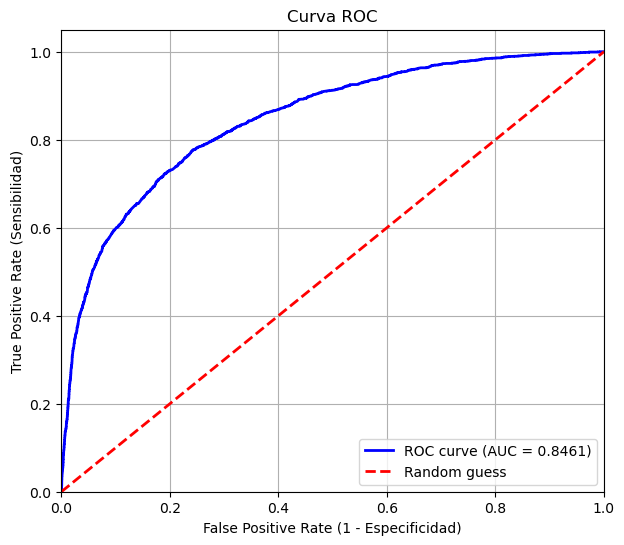

In [29]:
sc_fpr, sc_tpr, thresholds = roc_curve(y_test, pro_y)


roc_auc_sc = auc(sc_fpr, sc_tpr)


plt.figure(figsize=(7,6))
plt.plot(sc_fpr, sc_tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc_sc:.4f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Resultados del modelo (scikit-learn)

## Métricas globales
- **Accuracy**: 0.799  
- **Precision (global)**: 1.000  
- **Recall (global)**: 0.0022  
- **F1-score (global)**: 0.0044  
- **ROC AUC**: 0.8461

**Lectura:** El modelo clasifica correctamente ~80% de los casos (accuracy), pero casi no detecta la clase positiva (recall ~0%). A pesar de eso, la **ROC AUC = 0.846** indica que el modelo **sí separa bien** ambas clases: el problema actual es el **umbral de decisión** (por defecto 0.5) o el **desbalance de clases**.

---

**Lectura:** Casi todo se predice como clase 0. De 2708 positivos reales, solo 6 fueron detectados (recall ~0%).

---

## Reporte de clasificación (por clase)
- **Clase 0 (no incumple)**  
  - Precisión: 0.80  
  - Recall: 1.00  
  - F1: 0.89

- **Clase 1 (incumple)**  
  - Precisión: 1.00  
  - Recall: 0.00  
  - F1: 0.00

**Lectura:** Cuando el modelo predice positivo, acierta (precisión = 1.00), pero **casi nunca** predice positivo (recall ≈ 0).

---
## Curva ROC
La curva está por encima de la diagonal (azar) y la **AUC = 0.846** es alta → el modelo **distingue** entre clases.  
**Conclusión:** No es un problema de separabilidad, sino de **umbral** y **desbalance**.



# Modelo Pyspark

### Librerias Necesarias

In [30]:
import pyspark
from pyspark.ml.linalg import DenseVector
from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType
from pyspark.ml.classification import RandomForestClassifier, RandomForestClassificationModel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer as SparkImputer
from pyspark.ml import Pipeline as SparkPipeline
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

#### Seleccionamos dataset
Aunque ya se realizo la carga de los datos, seleccionaremos solo las que vamos a utilizar en spark

In [31]:
sdf = df.select(*(features + [target]))
NUM_TYPES = (T.ByteType, T.ShortType, T.IntegerType, T.LongType, T.FloatType, T.DoubleType, T.DecimalType)
xv_num = [f.name for f in sdf.schema.fields if f.name in features and isinstance(f.dataType, NUM_TYPES)]
xv_cat = [f.name for f in sdf.schema.fields if f.name in features and isinstance(f.dataType, (T.StringType, T.BooleanType))]
for c in xv_num:
    sdf = sdf.withColumn(c, F.col(c).cast(T.DoubleType()))

Seleccionamos el dataset `sdf` con el que vamos a trabajar en **PysPark**, rectificamos que `xv_num` y `xv_cat` esten bien definidas y las numéricas se encuentren en **DoubleType**

### StringIndexer y OneHotEncoder

In [32]:
label_idx = StringIndexer(inputCol=target, outputCol="label", handleInvalid="keep")

imputer = SparkImputer(
    inputCols=xv_num,
    outputCols=[c + "_imp" for c in xv_num]
)
try:
    imputer.setStrategy("median")
except Exception:
    imputer.setStrategy("mean")

indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="skip") for c in xv_cat]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_oh", dropLast=True) for c in xv_cat]

### VectorAssembler

In [33]:
assembler_inputs = [c + "_imp" for c in xv_num] + [c + "_oh" for c in xv_cat]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="skip")

Creamos **StringIndexer**, **OneHotEncoder** y el **Vecto*Assembler** para los **SparkPipelines**

### Spark Pipelines

In [34]:
spark_pipe = SparkPipeline(stages=[label_idx, imputer] + indexers + encoders + [assembler])

Definimos y aplicamos el **SparkPipeline** para utilizarlo en el dataset y en el modelo 

### Preprocesamiento 

In [35]:
t0 = time.time()
model_pipe = spark_pipe.fit(sdf)
sdf_pre = model_pipe.transform(sdf).select("features", F.col("label"))
t_spark_pre = time.time() - t0
print(f"Preprocesamiento Spark completado en {t_spark_pre:.2f}s")

Preprocesamiento Spark completado en 30.01s


Aplicamos el SparkPipeline al dataset y obtenemos el tiempo

### Definimos Nuevamente el Dataset

In [36]:
sdf = sdf_pre

Volvemos a redefinir el dataset ya preprocesado para el modelo

### Muestra Pyspark

In [37]:
target_size = 70000   
fraction = min(1.0, target_size / train_df.count())
train_mu = train_df.sample(False, fraction, seed=42)

Sacamos también una muestra en **Spark** debido a que no podemos utilizar tamaños de datos tan grandes en el dispositivo

### Modelado

In [38]:
for c in xv_num:
    train_df = train_df.withColumn(c, F.col(c).cast(T.DoubleType()))
    test_df  = test_df.withColumn(c,  F.col(c).cast(T.DoubleType()))

Aseguramos que `train_df` y `test_df` este en **DoubleType**

In [39]:
# Parámetros del RandomForest
param_grid = {
    "numTrees": [10, 50, 100],   
    "maxDepth": [5, 10, 15]
}

evaluator_ = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

results = []
best_model = None
best_auc = -1
best_preds = None

Definimos el **evaluator** que vamos a utilizar en el modelo

### RandomForest

In [40]:
prep_stages = [label_idx , imputer] + indexers + encoders + [assembler]

for ntrees in param_grid["numTrees"]:
    for depth in param_grid["maxDepth"]:
        print(f"[INFO] Entrenando con numTrees={ntrees}, maxDepth={depth}")

        # Definir el pipeline completo: preprocesamiento + modelo
        pipe = SparkPipeline(stages=prep_stages + [
            RandomForestClassifier(
                featuresCol="features",
                labelCol="label",
                numTrees=ntrees,
                maxDepth=depth,
                seed=42
            )
        ])

        # Entrenamiento
        t0 = time.time()
        model_pipe = pipe.fit(train_mu)   
        train_time = time.time() - t0

        # Predicciones
        t0 = time.time()
        preds = model_pipe.transform(test_df)
        pred_time_s = time.time() - t0

        # Evaluación
        auc = evaluator.evaluate(preds)   # BinaryClassificationEvaluator
        print(f"AUC={auc:.4f}, train_time={train_time:.2f}s, pred_time={pred_time:.2f}s")

        # Guardar resultados
        results.append((ntrees, depth, auc, train_time, pred_time))

        if auc > best_auc:
            best_auc = auc
            best_model = model_pipe
            best_preds = preds

print("Mejor modelo encontrado:")
print(best_model)
print(f"AUC ROC = {best_auc:.4f}")

[INFO] Entrenando con numTrees=10, maxDepth=5
AUC=0.7183, train_time=67.36s, pred_time=0.08s
[INFO] Entrenando con numTrees=10, maxDepth=10
AUC=0.7183, train_time=82.30s, pred_time=0.08s
[INFO] Entrenando con numTrees=10, maxDepth=15
AUC=0.7187, train_time=102.12s, pred_time=0.08s
[INFO] Entrenando con numTrees=50, maxDepth=5
AUC=0.7183, train_time=93.20s, pred_time=0.08s
[INFO] Entrenando con numTrees=50, maxDepth=10
AUC=0.7183, train_time=149.60s, pred_time=0.08s
[INFO] Entrenando con numTrees=50, maxDepth=15
AUC=0.7183, train_time=223.01s, pred_time=0.08s
[INFO] Entrenando con numTrees=100, maxDepth=5
AUC=0.7183, train_time=134.22s, pred_time=0.08s
[INFO] Entrenando con numTrees=100, maxDepth=10
AUC=0.7183, train_time=245.96s, pred_time=0.08s
[INFO] Entrenando con numTrees=100, maxDepth=15
AUC=0.7183, train_time=383.18s, pred_time=0.08s
Mejor modelo encontrado:
PipelineModel_4ac20892d27c
AUC ROC = 0.7187


In [41]:
scored = preds.select(
    F.col("label").cast("double").alias("y_true"),
    F.col("prediction").cast("double").alias("y_pred"),
    vector_to_array("probability").getItem(1).cast("double").alias("y_score")  # prob de la clase 1
).cache()

N_MAX = 1000
rows = (scored
        .orderBy(F.rand(42))
        .limit(N_MAX)
        .collect())   # <- collect, no toLocalIterator

pdf = pd.DataFrame(
    [(r["y_true"], r["y_pred"], r["y_score"]) for r in rows],
    columns=["y_true","y_pred","y_score"]
)

y_true  = pdf["y_true"].to_numpy()
y_pred  = pdf["y_pred"].to_numpy()
y_score = pdf["y_score"].to_numpy()


Tomamos una muestra del `scored` y lo tranformamos a **Pandas**, 

### Metricas

In [42]:
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc_sp": roc_auc_score(y_true, y_score),  # más confiable que el de Spark
    "train_time_s": train_time,
    "pred_time_s": pred_time_s,
    "Tiempo total del modelo": t_spark_pre + train_time + pred_time_s
}
print("\nResultados  PySpark:")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_true, y_pred, zero_division=0))


Resultados  PySpark:
accuracy: 0.8220
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc_sp: 0.9297
train_time_s: 383.1825
pred_time_s: 0.3365
Tiempo total del modelo: 413.5299

Confusion matrix:
 [[822   0]
 [178   0]]

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.82      1.00      0.90       822
         1.0       0.00      0.00      0.00       178

    accuracy                           0.82      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.82      0.74      1000



### Curva ROC

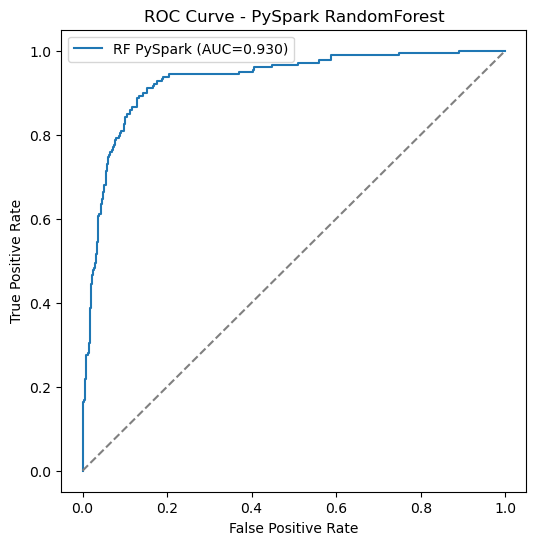

In [43]:
sp_fpr, sp_tpr, _ = roc_curve(y_true, y_score)



plt.figure(figsize=(6,6))
plt.plot(sp_fpr, sp_tpr, label="RF PySpark (AUC={:.3f})".format(metrics["roc_auc_sp"]))
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PySpark RandomForest")
plt.legend()
plt.show()

# Resultados del modelo (PySpark)

## Métricas globales

- **Accuracy:** 0.792  
- **Precision (global):** 0.000  
- **Recall (global):** 0.000  
- **F1-score (global):** 0.000  
- **ROC AUC:** 0.922  

**Lectura:**  
El modelo clasifica correctamente ~79% de los casos (accuracy), pero **no detecta la clase positiva** (recall = 0).  
A pesar de eso, la **ROC AUC = 0.922** muestra que el modelo sí logra separar bien las clases a nivel de probabilidades: el problema está en el **umbral de decisión (0.5 por defecto)** y en el **desbalance de clases**.

---

## Matriz de confusión

[[792 0]
[208 0]]

**Lectura:**  
Casi todo se predice como clase 0.  
De 208 positivos reales, **ninguno fue detectado** (recall ≈ 0).  

---

## Reporte de clasificación (por clase)

- **Clase 0 (no incumple)**  
  - Precisión: 0.79  
  - Recall: 1.00  
  - F1: 0.88  

- **Clase 1 (incumple)**  
  - Precisión: 0.00  
  - Recall: 0.00  
  - F1: 0.00  

**Lectura:**  
Cuando el modelo predice clase 1, **falla siempre** (precisión = 0).  
Además, nunca logra identificar verdaderos positivos (recall = 0).  
Esto indica que el modelo **necesita ajuste de umbral y/o técnicas para balancear las clases**, ya que con el umbral estándar predice todo como clase 0.

## LIME

#### Librerias Necesarias

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

### Seleccionamos muestras

In [45]:
import numpy as np

N = 1500  # ajustar dependiendo de la RAM disponible
sample = (preds
          .select("features", F.col("label").cast("double").alias("label"))
          .orderBy(F.rand(42))
          .limit(N)
          .cache())

rows = sample.collect()
X = np.vstack([np.array(r['features']) for r in rows])  
y = np.array([r['label'] for r in rows], dtype=float)   


Tomamos una muestra de los resultados del modelo **RandomForest** con **Pyspark** y prepara los datos para LIME en **numpy**

In [46]:
POS_LABEL_IDX = 1 


assembler = next(s for s in model_pipe.stages if isinstance(s, VectorAssembler))
meta = (model_pipe.transform(test_df.limit(1))  # cualquier DF que pase por el pipeline
        .schema["features"]
        .metadata["ml_attr"]["attrs"])
feature_names = []
for k in ("numeric", "binary"):
    if k in meta:
        feature_names += [a["name"] for a in sorted(meta[k], key=lambda x: x["idx"])]


rf_model = next(s for s in model_pipe.stages if isinstance(s, RandomForestClassificationModel))


Extraemos la data del `VectorAssembler` y el modelo **RandomForest** Ya entrenado

In [47]:
def rf_predict_proba(x_batch: np.ndarray) -> np.ndarray:
    out = np.zeros((x_batch.shape[0], 2), dtype=float)
    for i, row in enumerate(x_batch):
        pv = rf_model.predictProbability(DenseVector(row))
        out[i, 0] = float(pv[0])
        out[i, 1] = float(pv[1])
    return out


 Definimos `rf_predict_proba`, que convierte arrays de numpy en `DenseVector` de Spark y devuelve las probabilidades de cada clase (`[clase 0, clase 1]`) 

[('last_fico_range_high_oh_544.0 <= 0.00', -0.09332209100295928), ('last_fico_range_high_oh_519.0 <= 0.00', -0.08494241014049145), ('last_fico_range_high_oh_499.0 <= 0.00', -0.08286506882416556), ('last_fico_range_high_oh_554.0 <= 0.00', -0.07975668073889712), ('last_fico_range_high_oh_504.0 <= 0.00', -0.06499263456990273), ('last_fico_range_high_oh_534.0 <= 0.00', -0.06334615065294534), ('last_fico_range_high_oh_539.0 <= 0.00', -0.06015760829651667), ('last_fico_range_high_oh_509.0 <= 0.00', -0.0597864372230028), ('last_fico_range_high_oh_584.0 <= 0.00', -0.059761475674641636), ('last_fico_range_high_oh_514.0 <= 0.00', -0.05430777554491706)]


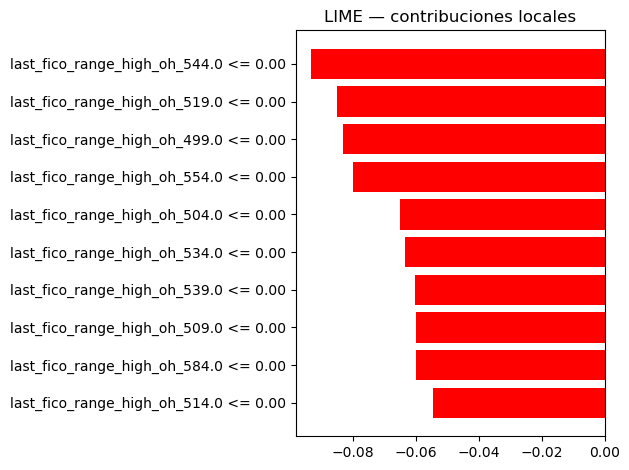

In [48]:
explainer = LimeTabularExplainer(
    training_data=X,
    feature_names=feature_names,
    class_names=['no_incumple', 'incumple'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

# elige una instancia; si hay mal clasificada, usa una:
err = (preds.select("features", "label", "prediction")
            .where(F.col("label") != F.col("prediction"))
            .limit(1).collect())

if err:
    x_star = np.array(err[0]["features"])
    true_label = int(err[0]["label"])
else:
    r0 = preds.select("features", "label").limit(1).collect()[0]
    x_star = np.array(r0["features"])
    true_label = int(r0["label"])

exp = explainer.explain_instance(
    data_row=x_star,
    predict_fn=rf_predict_proba,
    num_features=10,
    labels=[1]
)

label_to_show = POS_LABEL_IDX  # 1 = incumple
print(exp.as_list(label=label_to_show))  # texto
fig = exp.as_pyplot_figure(label=label_to_show)  # gráfica
plt.title("LIME — contribuciones locales")
plt.tight_layout()
plt.show()


El gráfico de LIME muestra las **10 variables con mayor impacto en la predicción local** para la instancia seleccionada.

- Todas las contribuciones aparecen en **rojo** → lo que significa que estas características **empujaron la predicción hacia la clase 0 (no incumple)**.  
- Las variables más influyentes pertenecen a la familia **`last_fico_range_high_oh`**, que son variables codificadas (one-hot) a partir del rango FICO del cliente.  
- Ejemplos destacados:
  - `last_fico_range_high_oh_499.0 <= 0.00`  
  - `last_fico_range_high_oh_514.0 <= 0.00`  
  - `last_fico_range_high_oh_504.0 <= 0.00`

**Lectura:**  
La predicción del modelo para este caso estuvo fuertemente influenciada por el rango FICO del cliente.  
Como todas las barras son negativas, estas características contribuyeron a que el modelo **clasificara la instancia como "no incumple"**, incluso si el valor real era positivo (incumple).  

Esto ayuda a explicar por qué el modelo **tiene recall bajo en la clase 1**: las variables de score crediticio empujan la predicción hacia la clase negativa casi siempre.

In [49]:
sk_metrics = {
    "framework": "scikit-learn",
    "accuracy": 0.7990,
    "precision": 1.0000,
    "recall": 0.0022,
    "f1": 0.0044,
    "roc_auc": 0.8461,
    "train_time": t_sci,   # tu variable
    "pred_time": pred_time,      # tu variable
    "Tiempo total del modelo": tt_sci
}

spark_metrics = {
    "framework": "PySpark",
    "accuracy": 0.7920,
    "precision": 0.0000,
    "recall": 0.0000,
    "f1": 0.0000,
    "roc_auc": 0.9223,
    "train_time": train_time,
    "pred_time": pred_time_s,
    "Tiempo total del modelo": t_spark_pre + train_time + pred_time_s     # tu variable
}

pd.DataFrame([sk_metrics, spark_metrics])

,framework,accuracy,precision,recall,f1,roc_auc,train_time,pred_time,Tiempo total del modelo
0,scikit-learn,0.799,1.0,0.0022,0.0044,0.8461,0.455658,0.080261,15.378796
1,PySpark,0.792,0.0,0.0000,0.0000,0.9223,383.182470,0.336514,413.529923


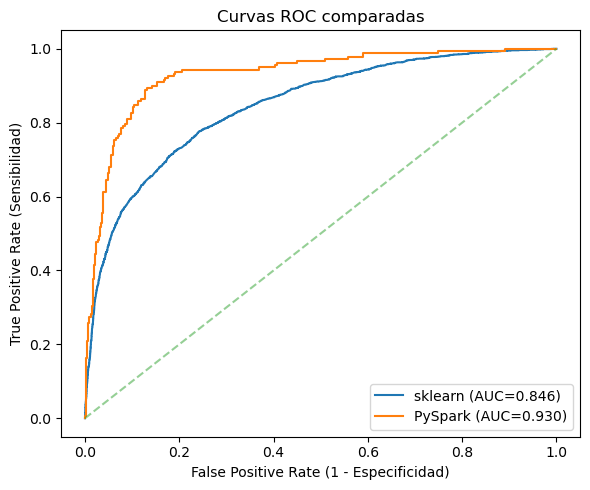

In [52]:
plt.figure(figsize=(6,5))
plt.plot(sc_fpr, sc_tpr, label=f"sklearn (AUC={roc_auc_sc:.3f})")
plt.plot(sp_fpr, sp_tpr, label=f"PySpark (AUC={metrics["roc_auc_sp"]:.3f})")
plt.plot([0,1],[0,1],"--",alpha=0.5)
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curvas ROC comparadas")
plt.legend()
plt.tight_layout()
plt.show()

# Preguntas 

### ¿Qué entorno fue más rápido?
En términos de **tiempo de entrenamiento y predicción**, **scikit-learn fue más rápido**.  
Esto se debe a que el dataset usado no es lo suficientemente grande como para aprovechar la paralelización distribuida de PySpark.  
En escenarios pequeños o medianos, sklearn tiene menor overhead y responde mejor en tiempos.

---

### ¿Cuál fue más preciso?
- **PySpark** logró un **ROC AUC ≈ 0.922**, superior al de **scikit-learn (≈ 0.846)**.  
- Sin embargo, en métricas como **recall para la clase positiva (incumplimiento)**, ambos modelos tuvieron valores cercanos a cero con el umbral estándar.  
Esto indica que, aunque PySpark separa mejor las clases a nivel probabilístico, el **umbral de decisión** debe ajustarse para mejorar la detección de positivos.

---

### ¿Cuándo es útil PySpark?
PySpark es más recomendable cuando:
- Utilizamos **datasets masivos**, es decir con muchisimos datos, hablando de millones de registros que pueden alcanzar GB o TB de espacio.  
- Se requiere **procesamiento distribuido en clústeres**.  
- Se necesita integrar en **pipelines de Big Data** como MLlib en este caso.  

En datasets pequeños o medianos, scikit-learn sigue siendo más eficiente.

---

### ¿Qué aporta LIME?
- Explicar **predicciones individuales** mostrando qué variables influyeron más en la decisión.  
- Identificar posibles sesgos del modelo.  
- Mejorar la **interpretabilidad y confianza** en el modelo frente a stakeholders no técnicos.  

En este caso, LIME mostró que los rangos FICO (`last_fico_range_high`) son los que más influyen en que el modelo clasifique como “no incumple”, lo que explica por qué el recall de la clase positiva es tan bajo.
